<a href="https://colab.research.google.com/github/glwat/Durham_Masters/blob/main/Crossformer_Air_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Codeblock Q001: Clone Crossformer repository
!git clone https://github.com/thinklab-sjtu/crossformer.git
%cd crossformer

fatal: destination path 'crossformer' already exists and is not an empty directory.
/content/crossformer


In [2]:
# Codeblock Q002: Install modern, Colab-compatible dependencies
!pip install einops numpy pandas torch

In [3]:
# Codeblock Q003: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install numpy==1.26.4

In [5]:
# Codeblock Q004: Load AirQuality XLSX from Google Drive
import pandas as pd

xlsx_path = "/content/drive/MyDrive/Masters_Colab_Data/AirQualityUCI.xlsx"
df = pd.read_excel(xlsx_path)

print(df.head())
print(df.info())

        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)   C6H6(GT)  \
0 2004-03-10  18:00:00     2.6      1360.00       150  11.881723   
1 2004-03-10  19:00:00     2.0      1292.25       112   9.397165   
2 2004-03-10  20:00:00     2.2      1402.00        88   8.997817   
3 2004-03-10  21:00:00     2.2      1375.50        80   9.228796   
4 2004-03-10  22:00:00     1.6      1272.25        51   6.518224   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0        1045.50    166.0       1056.25    113.0       1692.00      1267.50   
1         954.75    103.0       1173.75     92.0       1558.75       972.25   
2         939.25    131.0       1140.00    114.0       1554.50      1074.00   
3         948.25    172.0       1092.00    122.0       1583.75      1203.25   
4         835.50    131.0       1205.00    116.0       1490.00      1110.00   

       T         RH        AH  
0  13.60  48.875001  0.757754  
1  13.30  47.700000  0.725487  
2  11.90  53.975000 

In [6]:
# Codeblock Q005: Merge Date + Time and save clean CSV
df["timestamp"] = df["Date"].astype(str) + " " + df["Time"].astype(str)
df = df.drop(columns=["Date", "Time"])

# Move timestamp to the first column
cols = ["timestamp"] + [c for c in df.columns if c != "timestamp"]
df = df[cols]

df.info()

df.to_csv("./datasets/AirQuality_from_xlsx.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      9357 non-null   object 
 1   CO(GT)         9357 non-null   float64
 2   PT08.S1(CO)    9357 non-null   float64
 3   NMHC(GT)       9357 non-null   int64  
 4   C6H6(GT)       9357 non-null   float64
 5   PT08.S2(NMHC)  9357 non-null   float64
 6   NOx(GT)        9357 non-null   float64
 7   PT08.S3(NOx)   9357 non-null   float64
 8   NO2(GT)        9357 non-null   float64
 9   PT08.S4(NO2)   9357 non-null   float64
 10  PT08.S5(O3)    9357 non-null   float64
 11  T              9357 non-null   float64
 12  RH             9357 non-null   float64
 13  AH             9357 non-null   float64
dtypes: float64(12), int64(1), object(1)
memory usage: 1023.6+ KB


In [7]:
# Codeblock Q006: Train Crossformer using XLSX-derived dataset
!python main_crossformer.py \
  --data AirQuality \
  --data_path AirQuality_from_xlsx.csv \
  --data_dim 13 \
  --in_len 168 \
  --out_len 24 \
  --seg_len 6

Args in experiment:
Namespace(data='AirQuality', root_path='./datasets/', data_path='AirQuality_from_xlsx.csv', data_split=[0.7, 0.1, 0.2], checkpoints='./checkpoints/', in_len=168, out_len=24, seg_len=6, win_size=2, factor=10, data_dim=13, d_model=256, d_ff=512, n_heads=4, e_layers=3, dropout=0.2, baseline=False, num_workers=0, batch_size=32, train_epochs=20, patience=3, learning_rate=0.0001, lradj='type1', itr=1, save_pred=False, use_gpu=True, gpu=0, use_multi_gpu=False, devices='0,1,2,3')
Use GPU: cuda:0
>>>>>>>start training : Crossformer_AirQuality_il168_ol24_sl6_win2_fa10_dm256_nh4_el3_itr0>>>>>>>>>>>>>>>>>>>>>>>>>>
train 6358
val 914
test 1848
	iters: 100, epoch: 1 | loss: 0.4286311
	speed: 0.0318s/iter; left time: 123.5223s
Epoch: 1 cost time: 5.6671013832092285
Epoch: 1, Steps: 199 | Train Loss: 0.8573471 Vali Loss: 1.5865167 Test Loss: 0.6812389
Validation loss decreased (inf --> 1.586517).  Saving model ...
	iters: 100, epoch: 2 | loss: 0.7604521
	speed: 0.0248s/iter; left t

In [11]:
# Codeblock Q007: Evaluate using GitHub scripts

!python eval_crossformer.py \
  --setting_name Crossformer_AirQuality_il168_ol24_sl6_win2_fa10_dm256_nh4_el3_itr0 \
  --save_pred

Use GPU: cuda:0
mse:0.607362687587738, mae:0.42567068338394165


In [13]:
# Codeblock Q008: Define Predicted and True Shapes

import numpy as np

setting = "Crossformer_AirQuality_il168_ol24_sl6_win2_fa10_dm256_nh4_el3_itr0"

pred = np.load(f'./results/{setting}/pred.npy')
true = np.load(f'./results/{setting}/true.npy')

pred.shape, true.shape

((1848, 24, 13), (1848, 24, 13))

In [14]:
# Codeblock Q009: Report Metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(true.flatten(), pred.flatten())
mse = mean_squared_error(true.flatten(), pred.flatten())
rmse = np.sqrt(mse)
mape = np.mean(np.abs((true - pred) / true)) * 100

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 0.4256706237792969
MSE: 0.6073623895645142
RMSE: 0.7793345812707878
MAPE: 364.84718322753906


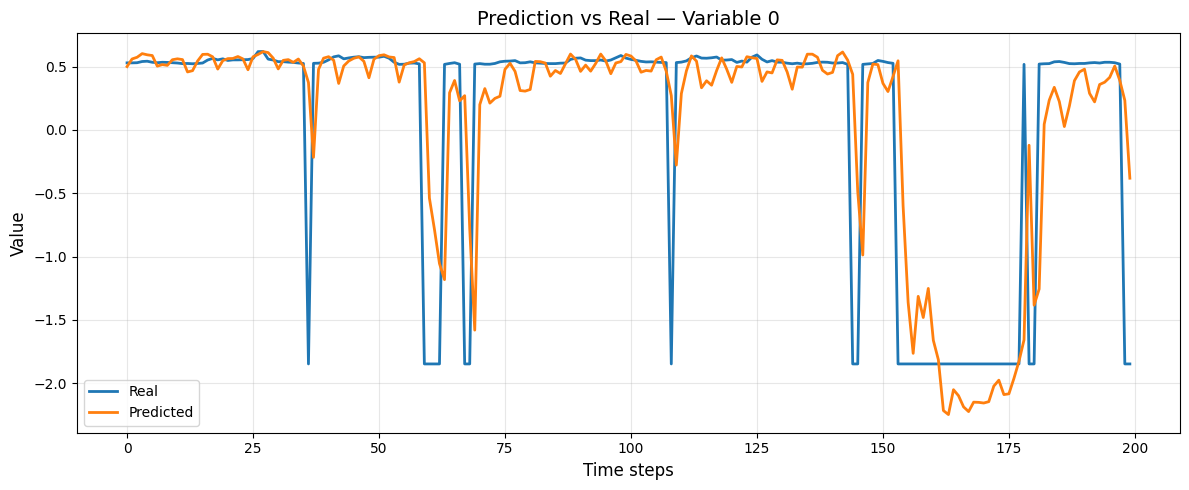

In [15]:
# Codeblock Q010: Graph Single Variable

import matplotlib.pyplot as plt

# Choose which variable to plot (0 = CO(GT))
var_index = 0

plt.figure(figsize=(12, 5))
plt.plot(true[:200, 0, var_index], label='Real', linewidth=2)
plt.plot(pred[:200, 0, var_index], label='Predicted', linewidth=2)

plt.title(f"Prediction vs Real — Variable {var_index}", fontsize=14)
plt.xlabel("Time steps", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

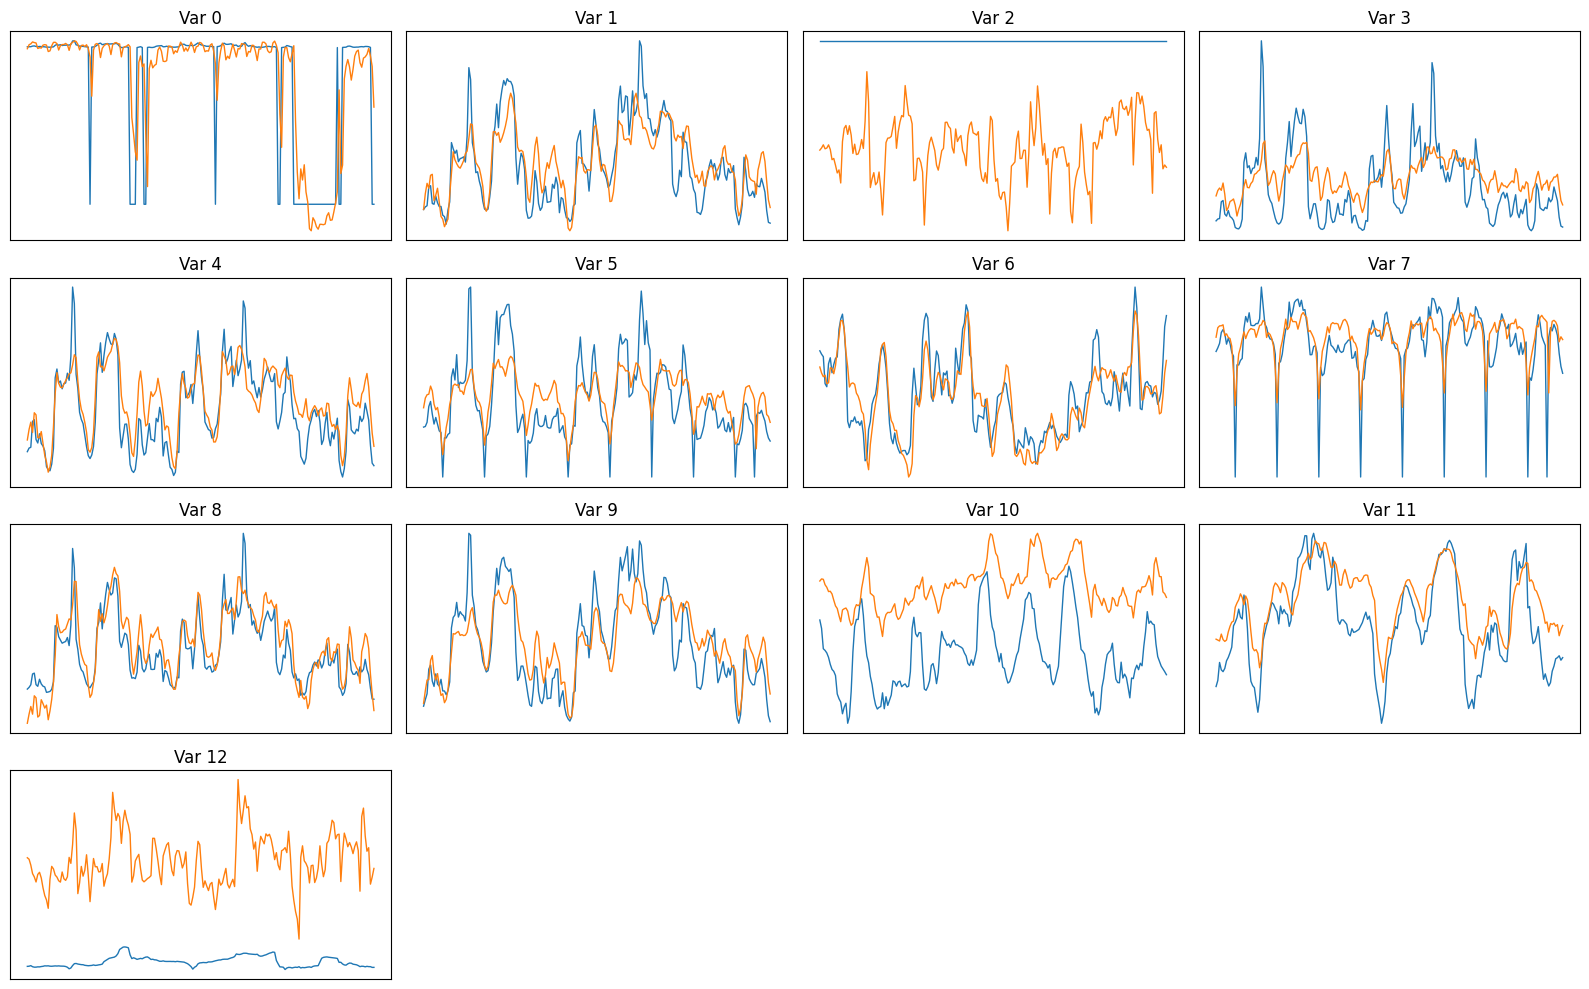

In [16]:
# Codeblock Q011: Graph all variables

num_vars = pred.shape[-1]
cols = 4
rows = int(np.ceil(num_vars / cols))

plt.figure(figsize=(16, 10))

for i in range(num_vars):
    plt.subplot(rows, cols, i+1)
    plt.plot(true[:200, 0, i], label='Real', linewidth=1)
    plt.plot(pred[:200, 0, i], label='Pred', linewidth=1)
    plt.title(f"Var {i}")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()